In [ ]:
project_path = "/content/drive/MyDrive/Colab Notebooks/scorewarrior"
data_path = f"{project_path}/data"

In [ ]:
!pip install catboost

In [ ]:
import pandas as pd
import numpy as np
import os
import yaml
from functools import partial
import shap
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from scipy.stats import ks_2samp, chi2_contingency
from typing import Optional, Tuple, List
import matplotlib.pyplot as plt
!sudo apt update
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q https://dlcdn.apache.org/spark/spark-3.2.1/spark-3.2.1-bin-hadoop3.2.tgz
!tar xf spark-3.2.1-bin-hadoop3.2.tgz
!pip install -q findspark
!pip install pyspark
!pip install py4j

import findspark
findspark.init()
findspark.find()


from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import seaborn as sns
import joblib
os.sys.path.append(f"{project_path}/ml-pipeline-main/models/classifiers")
from split_factory import create_folds
from pathlib import Path
from model_factory import LGBMModel
from logger_config import logger

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 https://cli.github.com/packages stable InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
43 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as re

In [ ]:
def get_metrics(df, target_name:str='target', pred_name:str='cv_pred'):
  rmse = np.sqrt(mean_squared_error(y_true=df[target_name], y_pred=df[pred_name]))
  mae = mean_absolute_error(y_true=df[target_name], y_pred=df[pred_name])
  mape = mean_absolute_percentage_error(y_true=df[target_name], y_pred=df[pred_name])
  return {'rmse':rmse, 'mae':mae, 'mape':mape}

In [ ]:
def get_shap_descr(trainer):
  features = trainer.model_dict[0].feature_name()
  X = trainer.df[trainer.df['fold'] == 0][features]
  explainer = shap.TreeExplainer(trainer.model_dict[0])
  shap_values = explainer(X)
  shap.summary_plot(shap_values, X)

  feature_importance = np.abs(shap_values.values).mean(axis=0)
  feature_importance_df = pd.DataFrame(
      {'feature': features, 'shap_importance': feature_importance}
  )

  # Сортировка признаков по важности в порядке убывания
  top_features_df = feature_importance_df.sort_values(by='shap_importance', ascending=False)
  return top_features_df

In [ ]:
def predict(trainer, test):
  predict = pd.Series(index=test.index, data=np.zeros(test.shape[0]))
  models_len = len(trainer.model_dict.keys())
  for model in trainer.model_dict.values():
    predict += (
        model.predict(
            test[model.feature_name()], num_iteration=model.num_trees()
        )
        / models_len
    )
  return predict

In [ ]:
spark= SparkSession \
       .builder \
       .appName("Our First Spark Example") \
       .getOrCreate()

spark

# Load data

In [ ]:
df = pd.read_csv(f"{data_path}/user_profile.csv")
test_df = pd.read_csv(f"{data_path}/user_profile_test.csv")

In [ ]:
daily_features = spark.read.csv(f"{data_path}/features/daily.csv",
                                header=True,
                                inferSchema=True).toPandas()
categories = spark.read.csv(f"{data_path}/features/category.csv",
                            header=True, inferSchema=True).toPandas()

entry_features = spark.read.csv(f"{data_path}/features/entry_features.csv",
                                 header=True,
                                inferSchema=True ).toPandas()

country_features = spark.read.csv(f"{data_path}/features/country_features.csv",
                                 header=True,
                                inferSchema=True ).toPandas()

In [ ]:
daily_features = daily_features.rename(columns={"fs_client_id":"user_id"})
categories = categories.rename(columns={"fs_client_id":"user_id"})

entry_features_features = {feat:feat+"_entry" for feat in entry_features.columns if feat.startswith("f_")}
country_features_features = {feat:feat+"_country" for feat in country_features.columns if feat.startswith("f_")}

entry_features = entry_features.rename(columns={"fs_client_id": "entry_point"}).rename(columns=entry_features_features)
country_features = country_features.rename(columns={"fs_client_id": "country"}).rename(columns=country_features_features)

In [ ]:
df = pd.merge(df, daily_features, on=['user_id'], how='left')
df = pd.merge(df, categories, on=['user_id'], how='left')
df = pd.merge(df, entry_features, on=['entry_point', 'fs_sample_date'], how='left')
df = pd.merge(df, country_features, on=['country', 'fs_sample_date'], how='left')

In [ ]:
test_df = pd.merge(test_df, daily_features, on=['user_id'], how='left')
test_df = pd.merge(test_df, categories, on=['user_id'], how='left')
test_df = pd.merge(test_df, entry_features, on=['entry_point', 'fs_sample_date'], how='left')
test_df = pd.merge(test_df, country_features, on=['country', 'fs_sample_date'], how='left')

In [ ]:
df_folds_5 = create_folds(df, target_column="target", n_folds=5, stratify_type="KFold")

In [ ]:
df_folds_5.to_csv(f"{data_path}/train.csv")
test_df.to_csv(f"{data_path}/test.csv")

In [ ]:
df['target'].describe(percentiles=[.25, .5, .75, .9, .95, .99])

,target
count,4862.000000
mean,145.236291
std,909.308029
min,0.000000
25%,0.000000
50%,0.000000
75%,27.720661
90%,137.611502
95%,432.131938
99%,3311.737624


/tmp/ipython-input-830137014.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log1p(df['target'] - df['f_Interval_sum_payment_prev7days'].fillna(0)), label="log_target")


<Axes: ylabel='Density'>

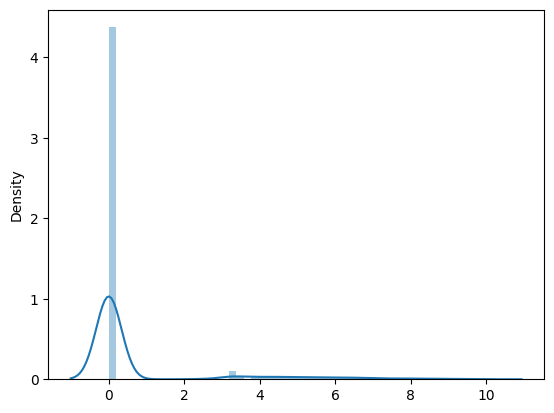

In [ ]:
sns.distplot(np.log1p(df['target'] - df['f_Interval_sum_payment_prev7days'].fillna(0)), label="log_target")

In [ ]:
daily_features = [col for col in df.columns if col.startswith("f_") and col not in df.loc[:, df.dtypes == object].columns]

In [ ]:
CATEGORIES = ["country_ind", "entry_point_ind"]
N_FOLDS = 5
SAVE_MODEL = False
PREDICT_MODEL = True

#  Exps

## LTV30-LTV7>0

In [ ]:
df_folds_5.loc[np.round(df_folds_5['target'], 9)>np.round(df_folds_5['f_Interval_sum_payment_prev7days'], 9), 'binary_target'] = 1
df_folds_5['binary_target'] = df_folds_5['binary_target'].fillna(0)

In [ ]:
lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.1,

    "num_leaves": 64,
    "max_depth": 6,

    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbosity": -1,
    "seed": 42,
    "num_boost_round": 1000,

    "early_stopping_rounds": 100,
    "n_jobs": 64,
}
TARGET_NAME = "binary_target"
trainer_bin = LGBMModel(params=lgb_params, model_name="lgbm", cat_features=CATEGORIES)

In [ ]:
avg_auc, std_auc = trainer_bin.train_folds(
    df=df_folds_5,
    folds=range(N_FOLDS),
    feature_space=CATEGORIES+daily_features,
    target_name=TARGET_NAME,
    save_model=SAVE_MODEL,
    predict_model=True,
)

print(f"\nMean AUC: {avg_auc:.5f} ± {std_auc:.5f}")


Mean AUC: 0.95103 ± 0.00692


In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
roc_auc_score(y_score=df_folds_5['f_Interval_min_payment_prev7days'].fillna(0), y_true=df_folds_5['binary_target'])

np.float64(0.8735569209863306)

In [ ]:
top_n = 10
f_log_top_list = list(top_features_df.head(top_n)['feature'])
avg_auc, std_auc = trainer_bin.train_folds(
    df=df_folds_5,
    folds=range(N_FOLDS),
    feature_space=f_log_top_list,
    target_name=TARGET_NAME,
    save_model=SAVE_MODEL,
    predict_model=True,
)

print(f"\nMean AUC: {avg_auc:.5f} ± {std_auc:.5f}")


Mean AUC: 0.95207 ± 0.00783


In [ ]:
joblib.dump(trainer_bin, f"{project_path}/artifacts/trainer_bin.pickle")

['/content/drive/MyDrive/Colab Notebooks/scorewarrior/artifacts/trainer_bin.pickle']

/tmp/ipython-input-1159779514.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X)


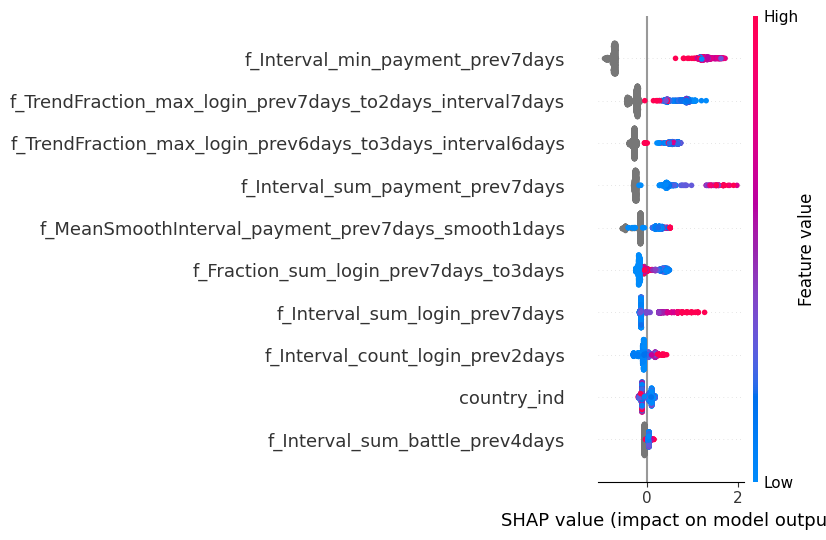

In [ ]:
top_features_df = get_shap_descr(trainer_bin)

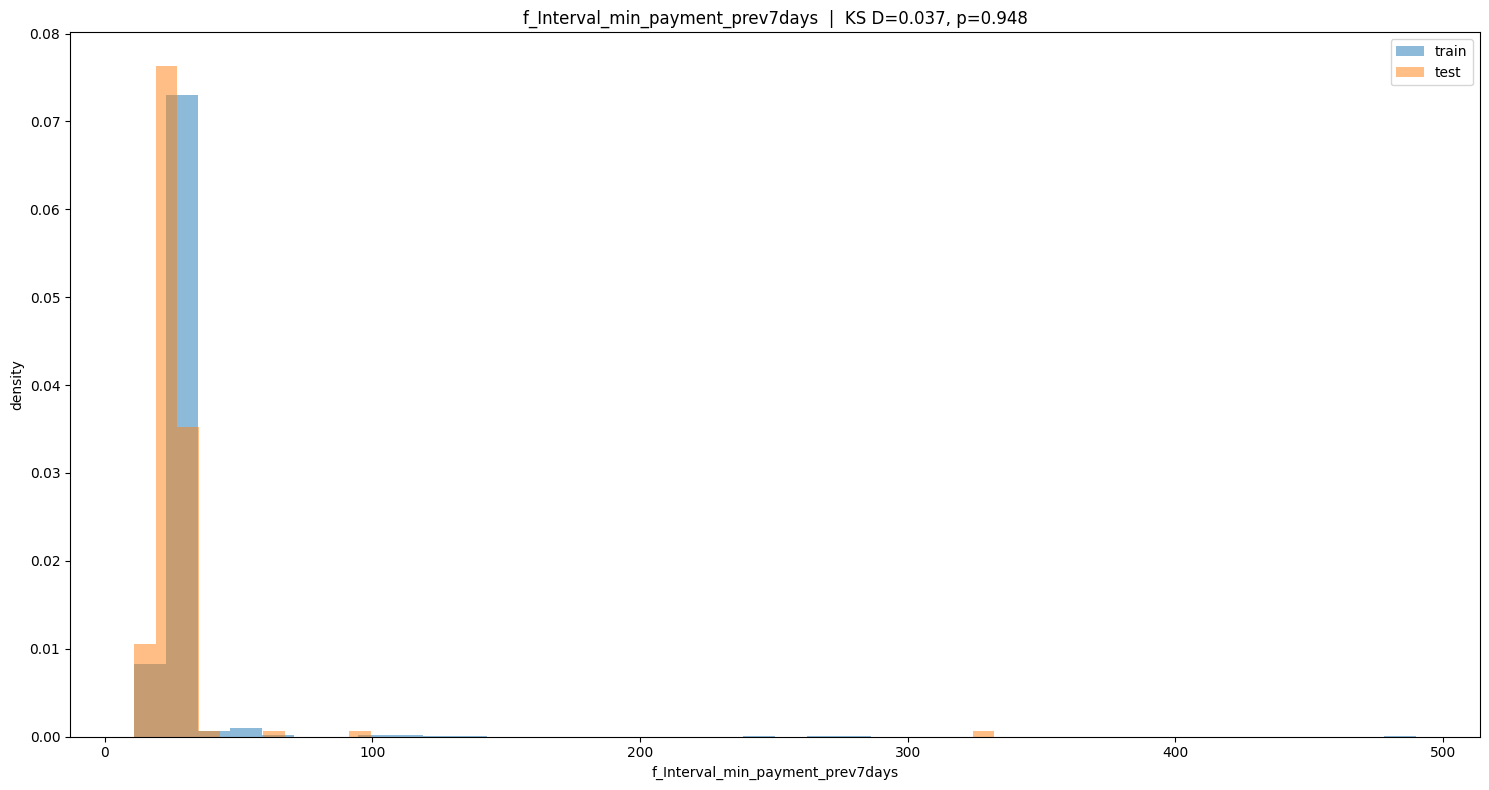

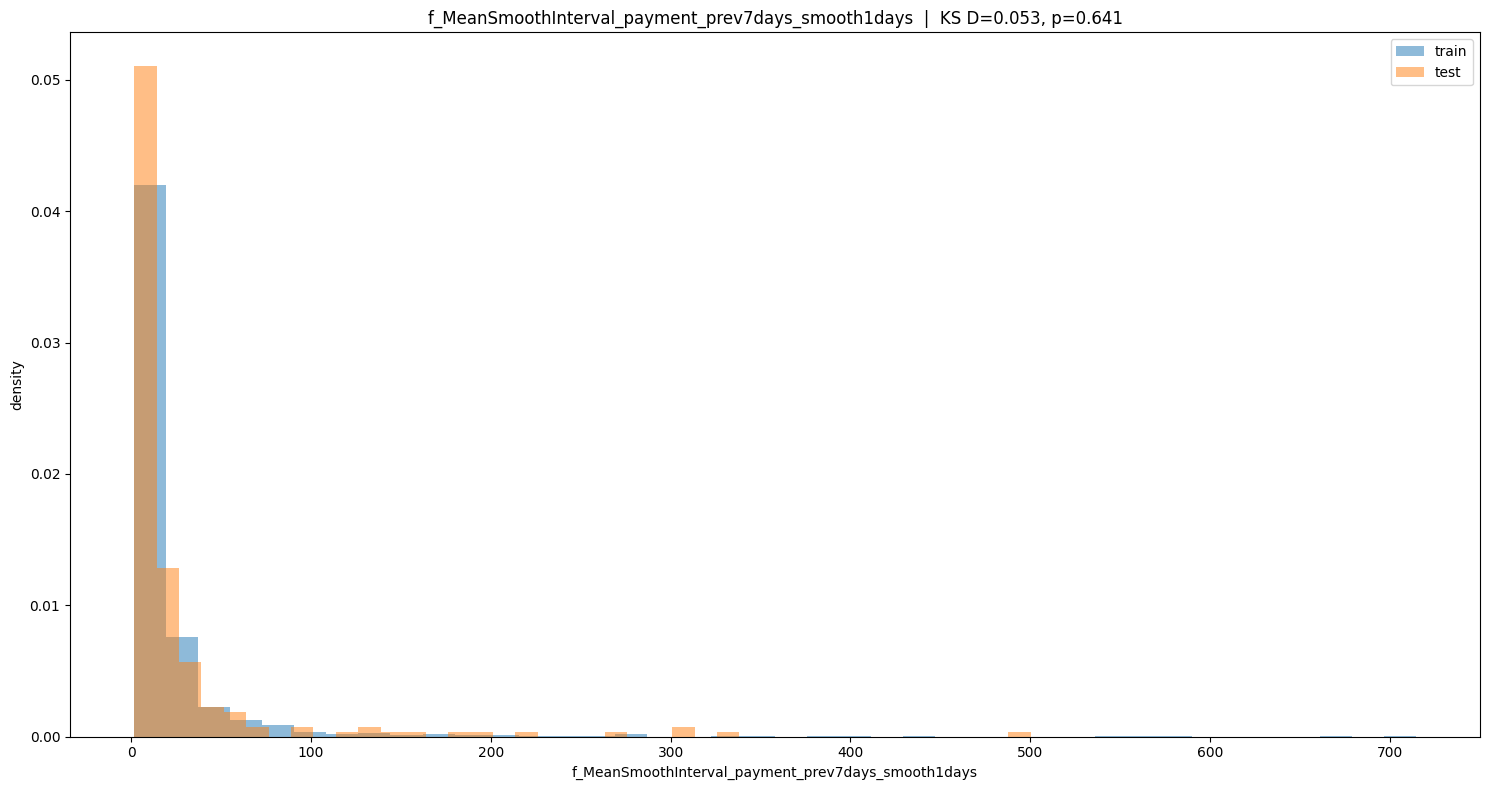

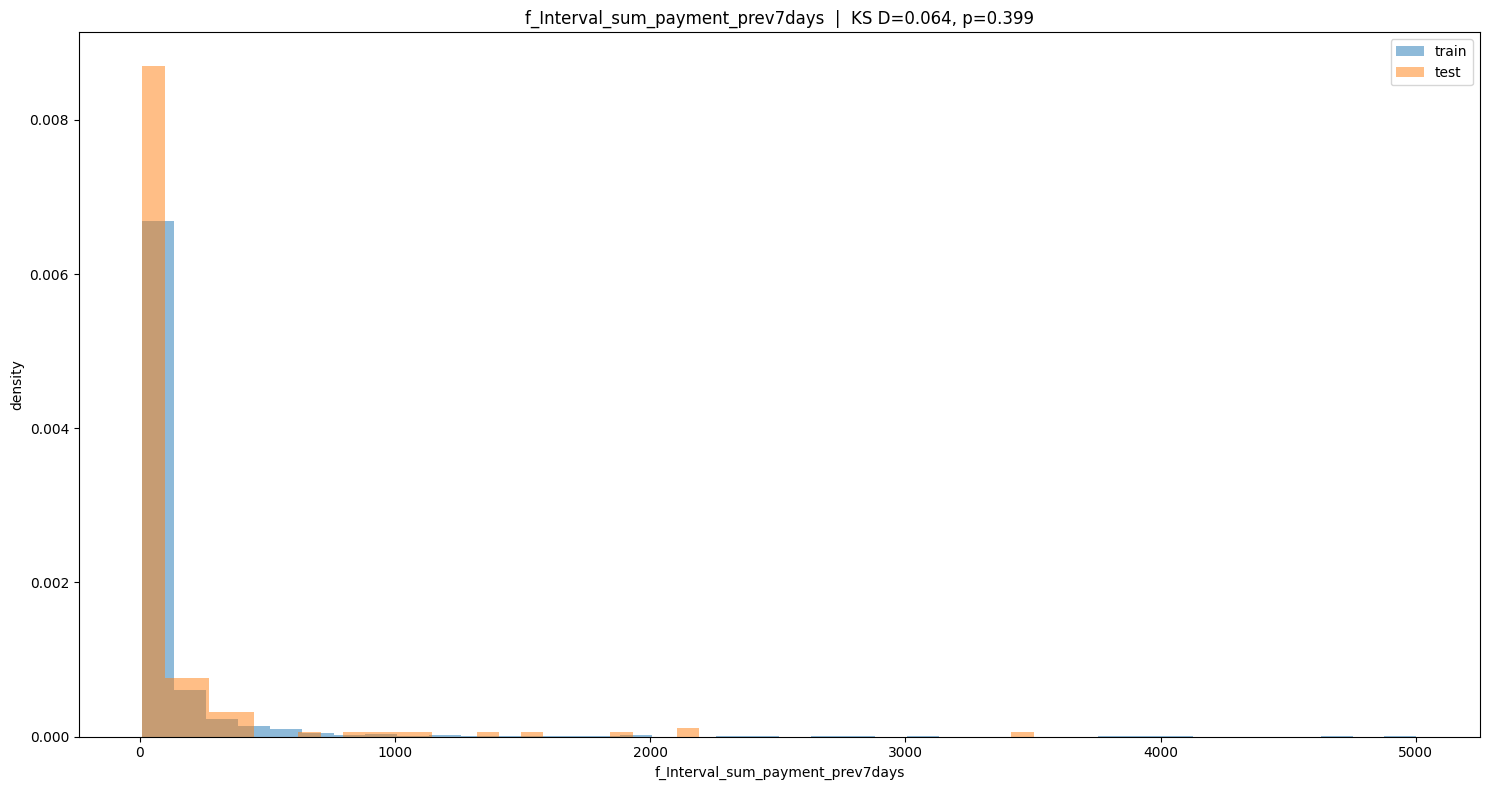

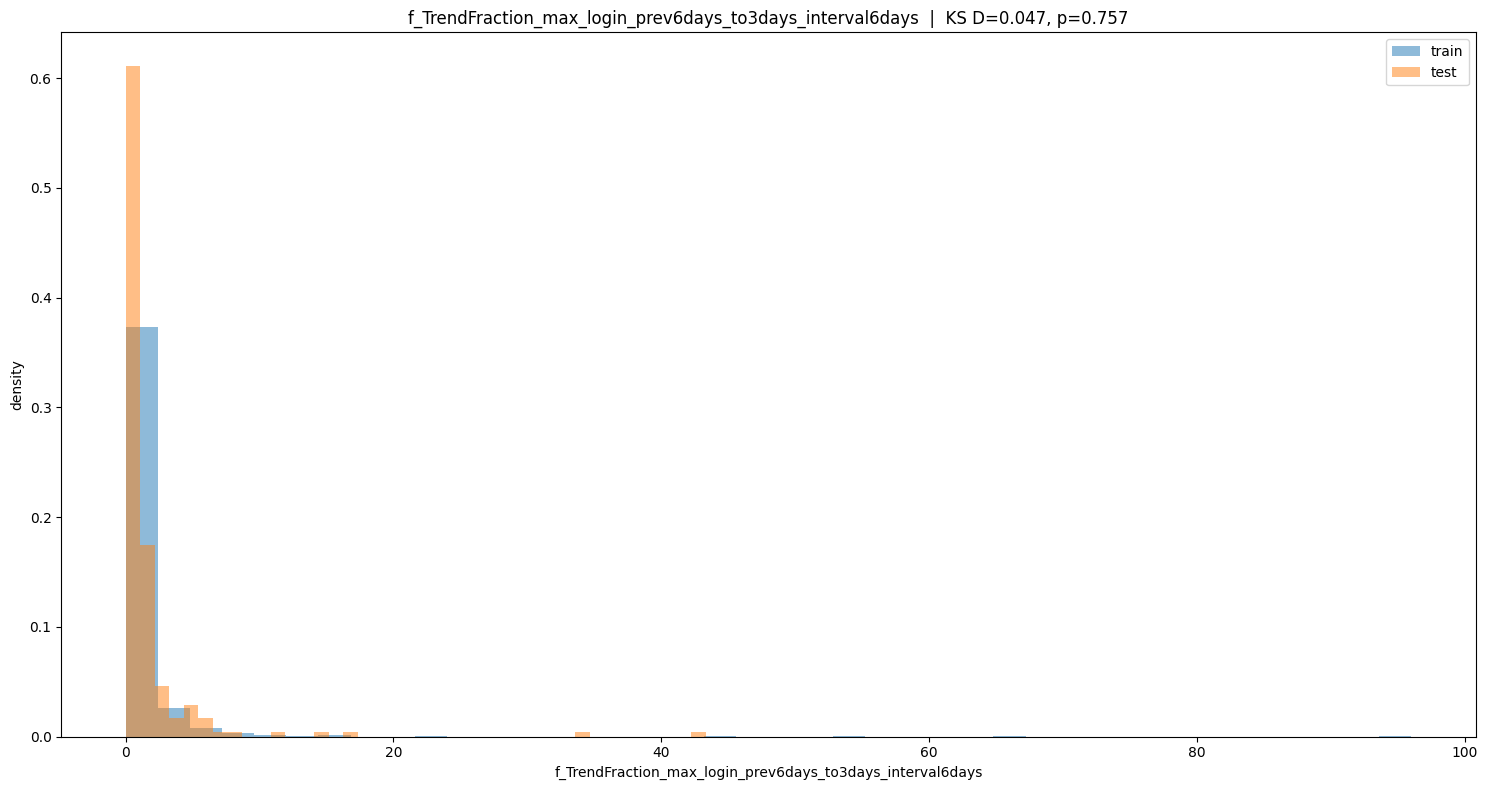

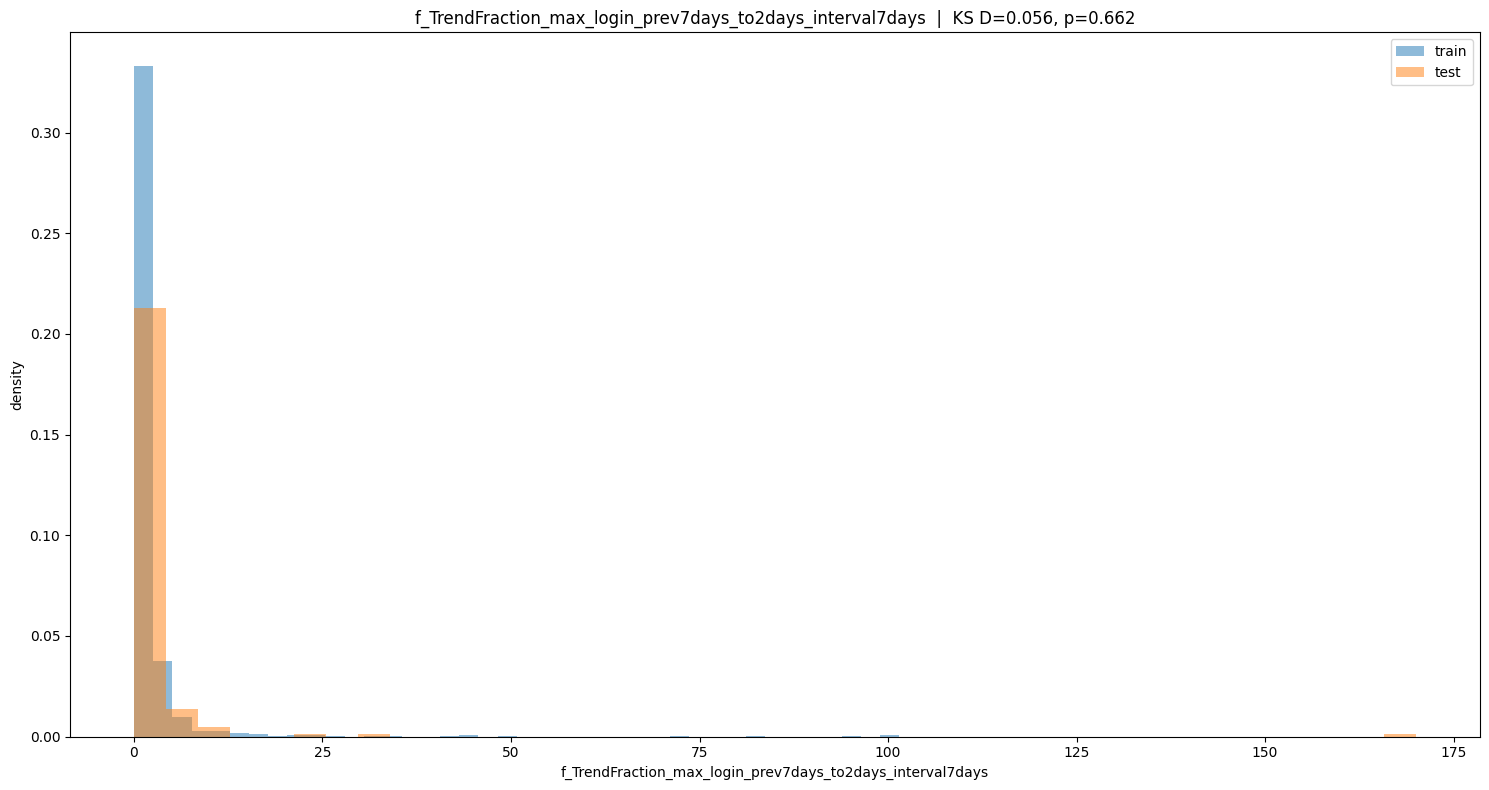

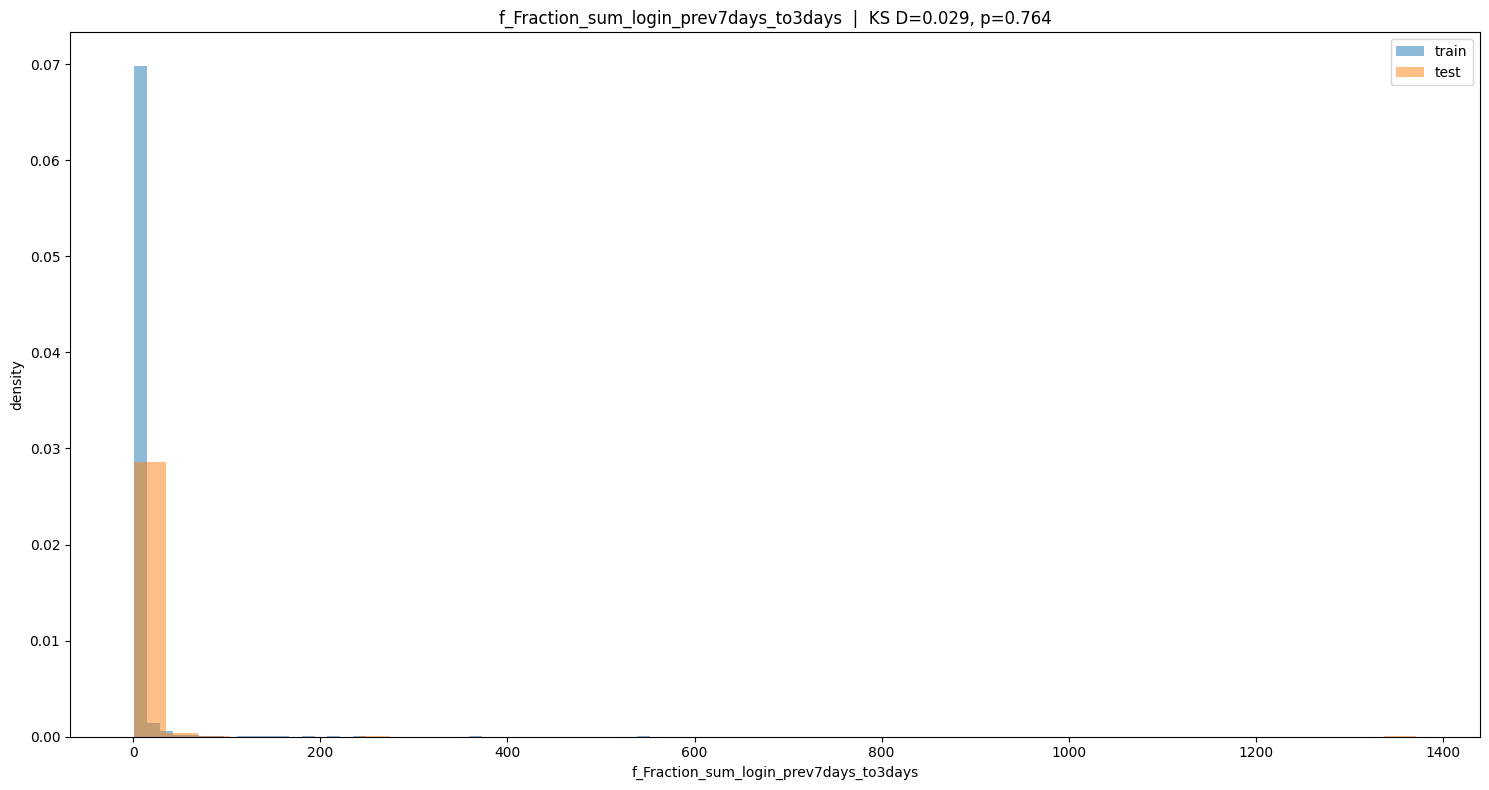

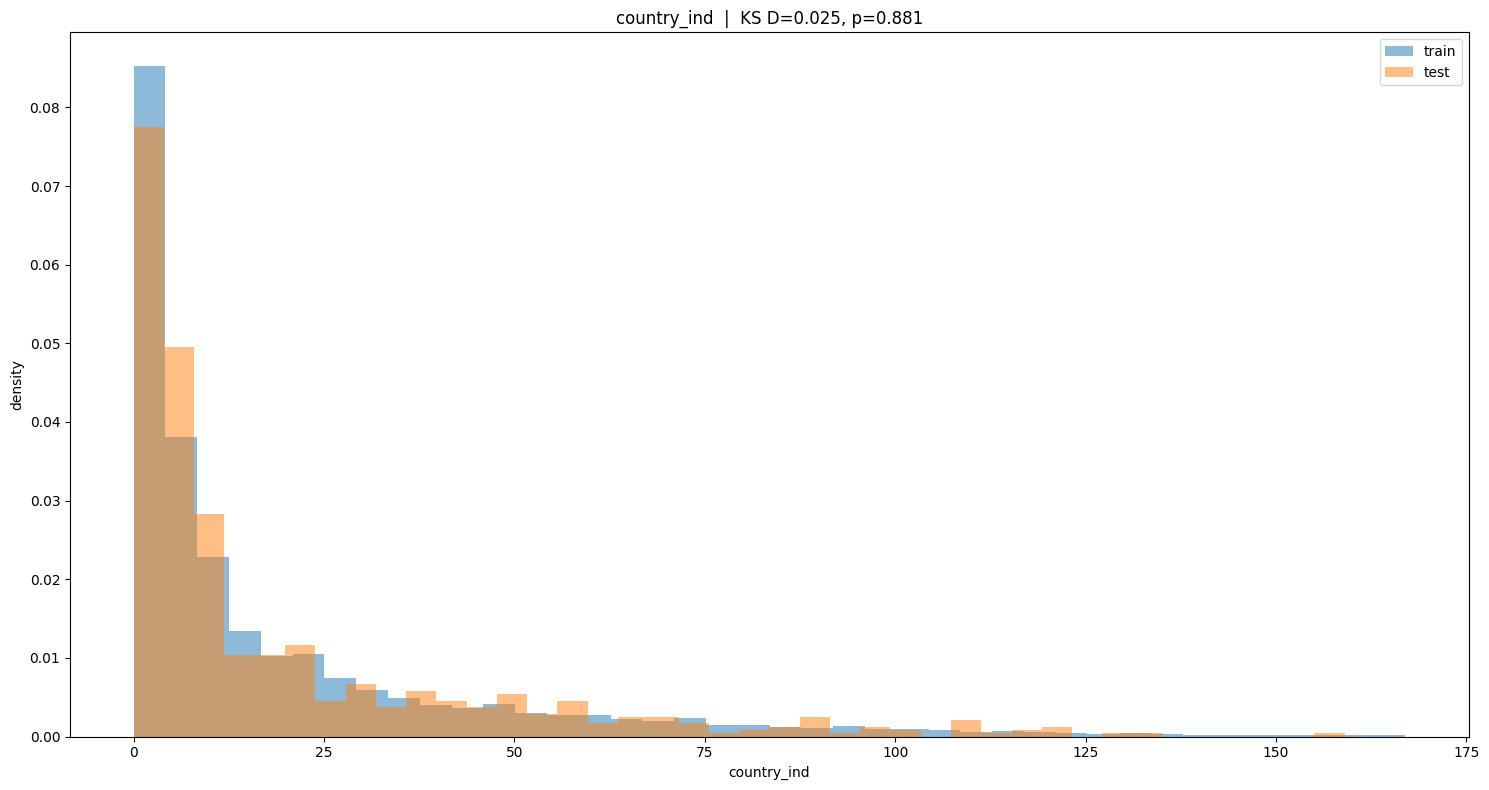

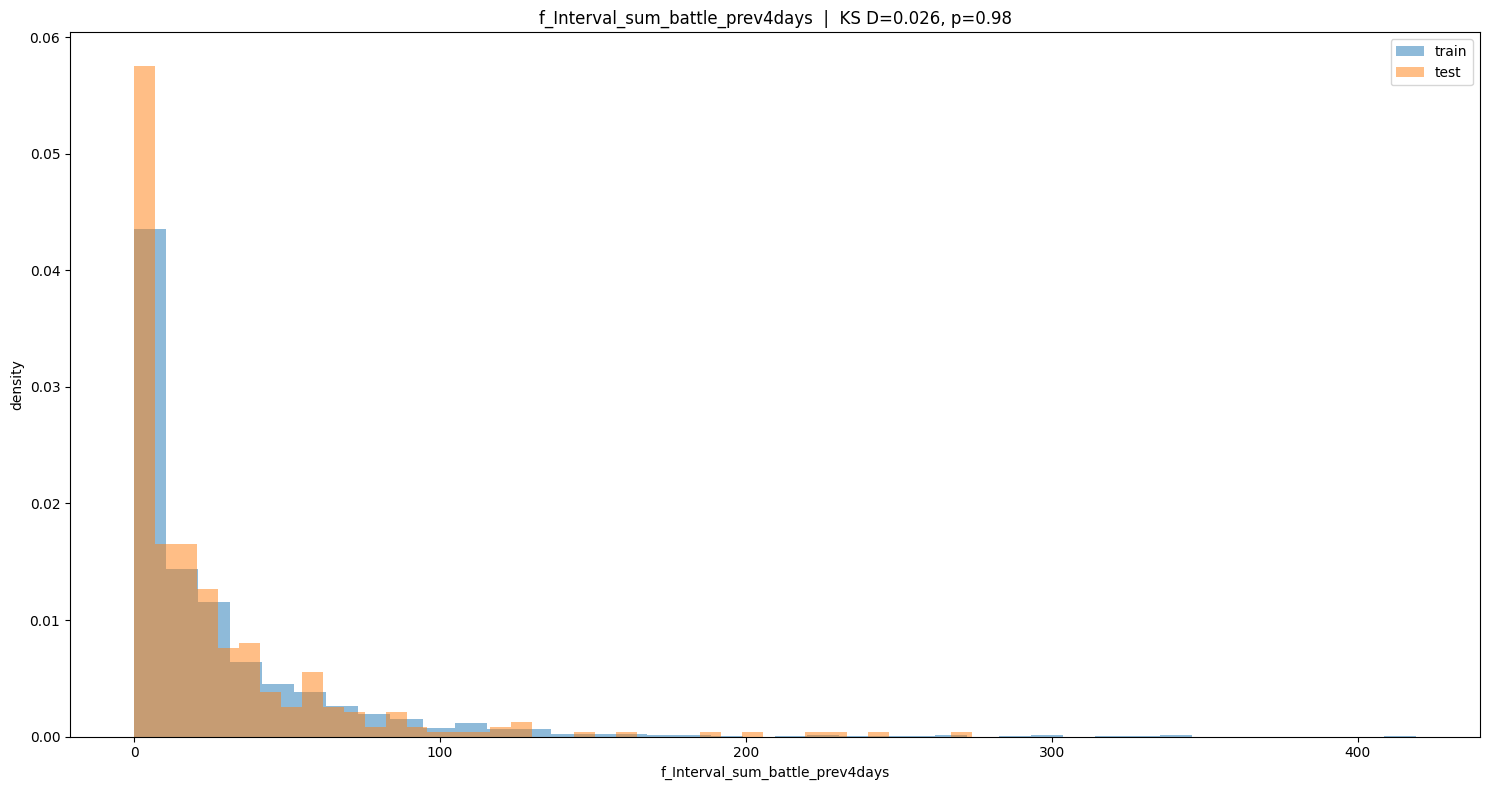

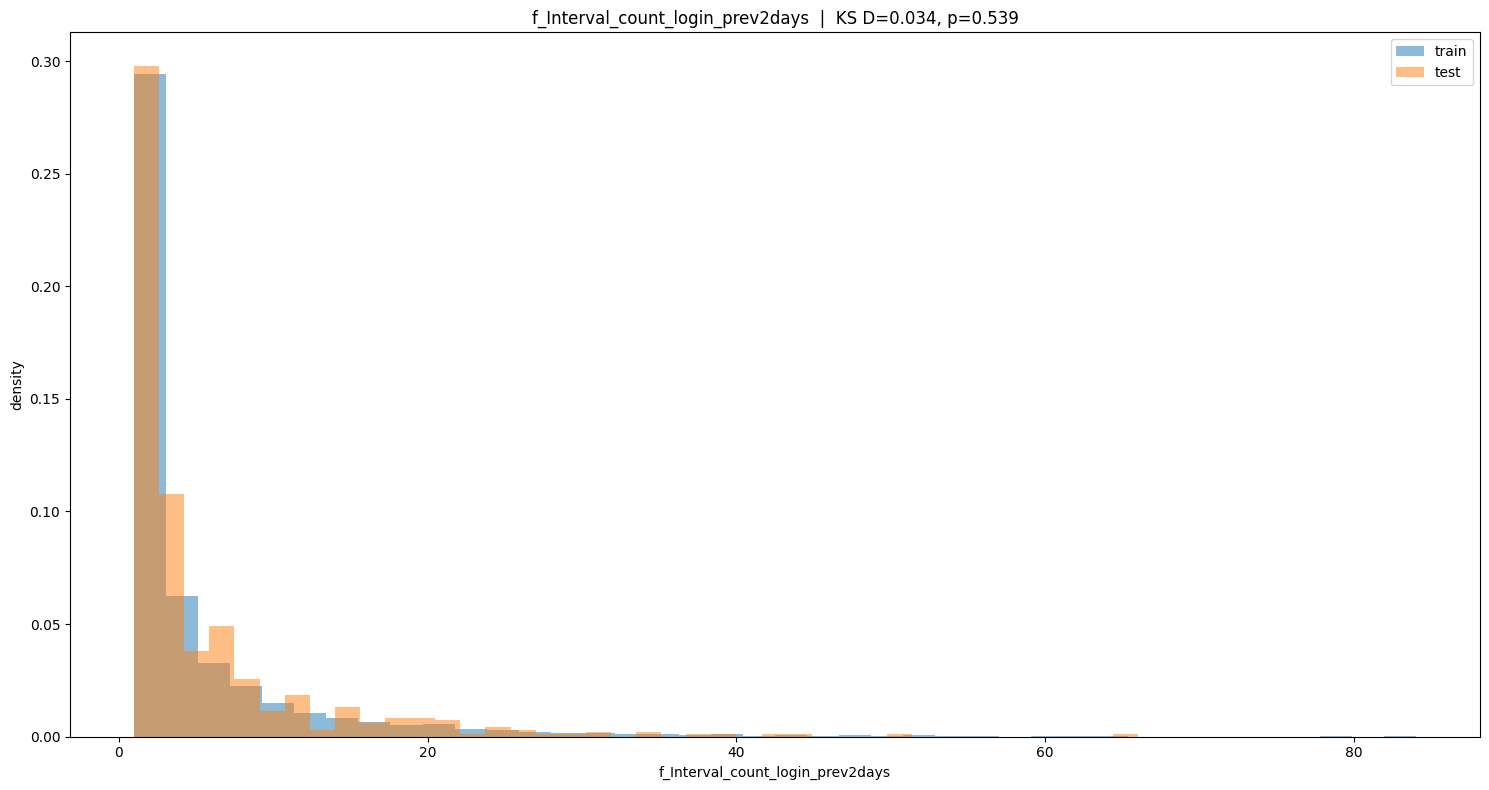

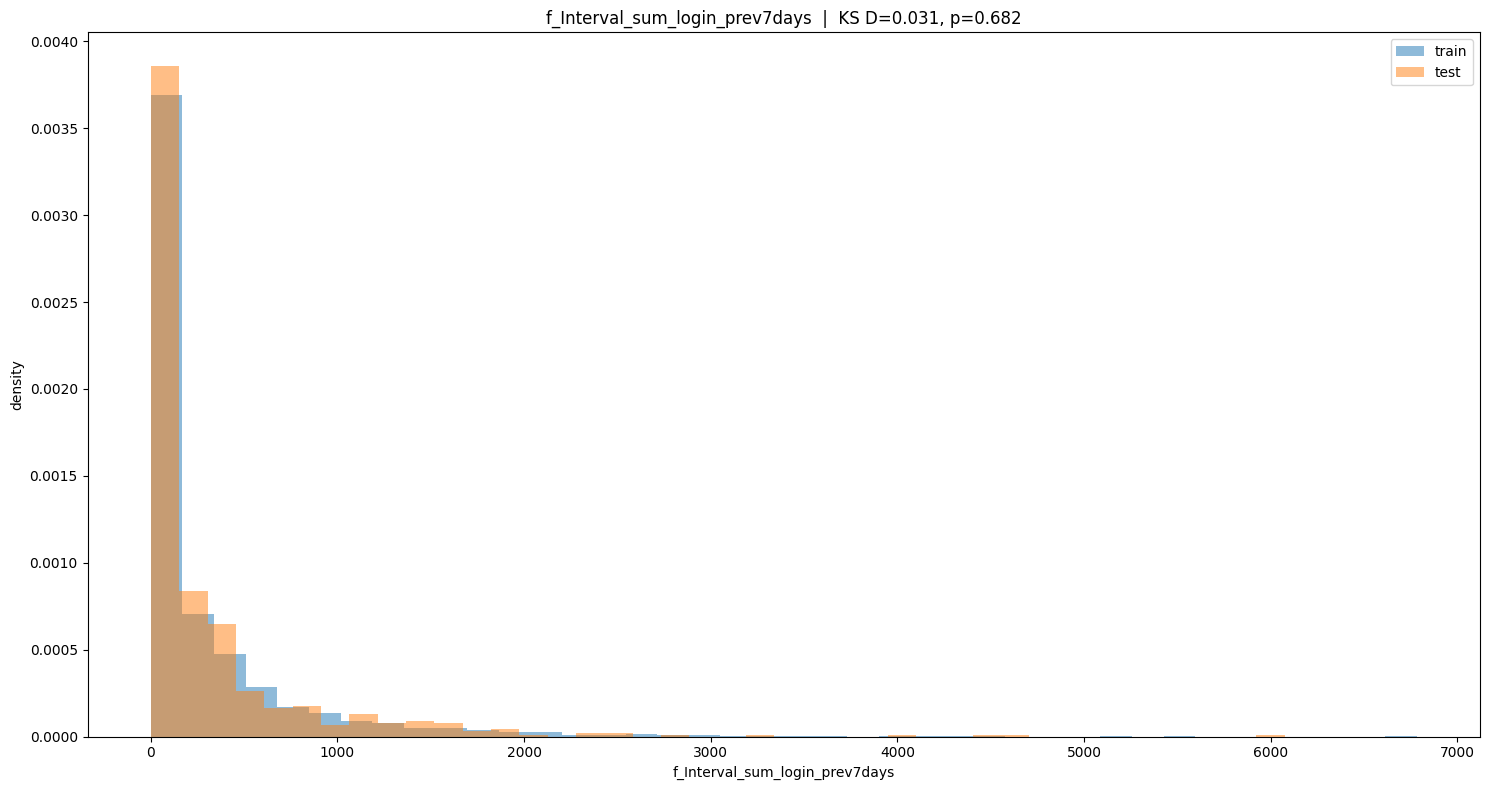

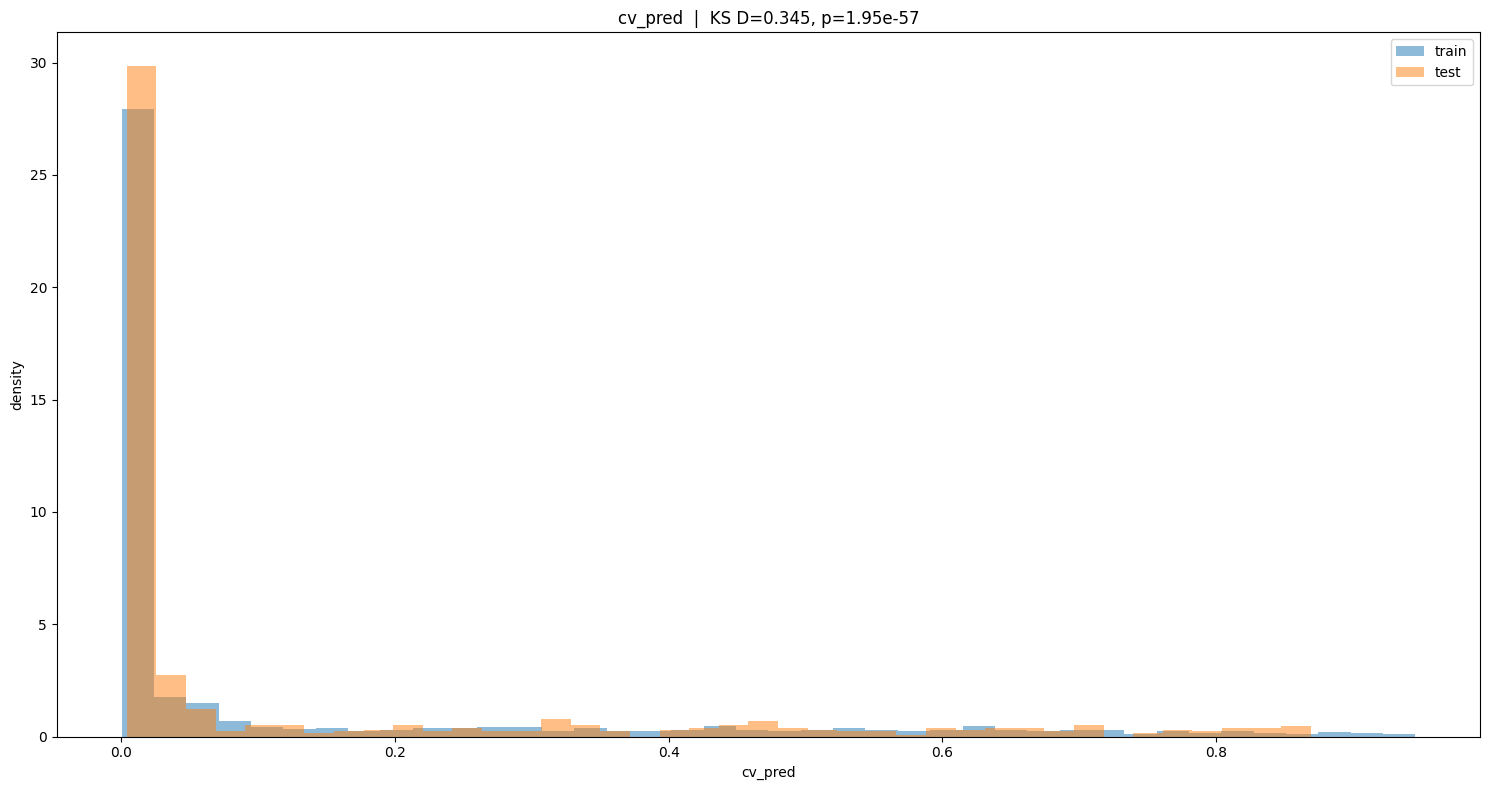

                                              feature     type  train_mean  \
10                                            cv_pred  numeric    0.122994   
2                    f_Interval_sum_payment_prev7days  numeric  127.741548   
8                    f_Interval_count_login_prev2days  numeric    5.218122   
1   f_MeanSmoothInterval_payment_prev7days_smooth1...  numeric   22.798646   
4   f_TrendFraction_max_login_prev7days_to2days_in...  numeric    2.274426   
9                      f_Interval_sum_login_prev7days  numeric  286.130002   
3   f_TrendFraction_max_login_prev6days_to3days_in...  numeric    1.582666   
5              f_Fraction_sum_login_prev7days_to3days  numeric    3.968073   
6                                         country_ind  numeric   19.545043   
0                    f_Interval_min_payment_prev7days  numeric   27.131715   
7                     f_Interval_sum_battle_prev4days  numeric   26.860668   

     train_std   test_mean    test_std      stat       p_value 

In [ ]:

summary = compare_feature_distributions(
    trainer_bin.df,
    test_df.rename(columns={"binary_cv":"cv_pred"}),
    features=f_log_top_list + ['cv_pred'],
    bins=40,
    max_cat=15,
    sample=5000,
    dropna=True
)
print(summary.sort_values("p_value"))

## Регрессоры

In [ ]:
df_regr = df.copy()
df_regr['actual_target'] = df_regr['target']-df_regr['f_Interval_sum_payment_prev7days'].fillna(0)
df_regr['actual_rate_target'] = (df_regr['actual_target'])/(df_regr['f_Interval_sum_payment_prev7days'])
df_regr['actual_log_rate_target'] = np.log(df_regr['actual_rate_target']+1)

df_regr = df_regr[np.round(df_regr['actual_target'], 9)>0].reset_index()
df_regr = create_folds(df_regr, target_column="actual_log_rate_target", n_folds=10, stratify_type="KFold")

### np.log(target/prev_LTV7+1)

#### on all train

In [ ]:
df_folds_5['actual_target'] = df_folds_5['target']-df_folds_5['f_Interval_sum_payment_prev7days'].fillna(0)
df_folds_5['actual_rate_target'] = (df_folds_5['actual_target'])/(df_folds_5['f_Interval_sum_payment_prev7days'])
df_folds_5['actual_log_rate_target'] = np.log(df_folds_5['actual_rate_target']+1)

/tmp/ipython-input-1044922492.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_folds_5['actual_log_rate_target'])


<Axes: xlabel='actual_log_rate_target', ylabel='Density'>

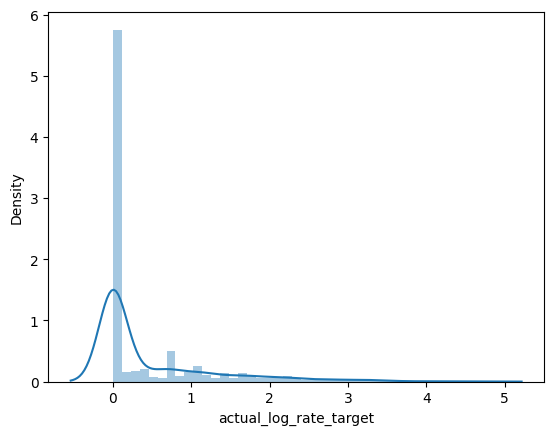

In [ ]:
sns.distplot(df_folds_5['actual_log_rate_target'])

In [ ]:
lgb_params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "reg_alpha":2.0,
    "reg_lambda":5.0,
    "min_child_samples":30,
    "max_depth": 3,
    "num_leaves":8,
    "verbosity": -1,
    "seed": 42,
    "num_boost_round": 1000,
    "early_stopping_rounds": 100,
    "n_jobs": 64,
}

TARGET_NAME = "actual_log_rate_target"
trainer_actual_log_rate_full = LGBMModel(params=lgb_params, model_name="lgbm", cat_features=CATEGORIES)

In [ ]:
avg_rmse, std_rmse = trainer_actual_log_rate_full.train_folds(
    df=df_folds_5,
    folds=range(N_FOLDS),
    feature_space=CATEGORIES+daily_features,
    target_name=TARGET_NAME,
    save_model=SAVE_MODEL,
    predict_model=True,
)

print(f"\nMean RMSE: {avg_rmse:.5f} ± {std_rmse:.5f}")


Mean RMSE: 0.40985 ± 0.02876


/tmp/ipython-input-1159779514.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X)


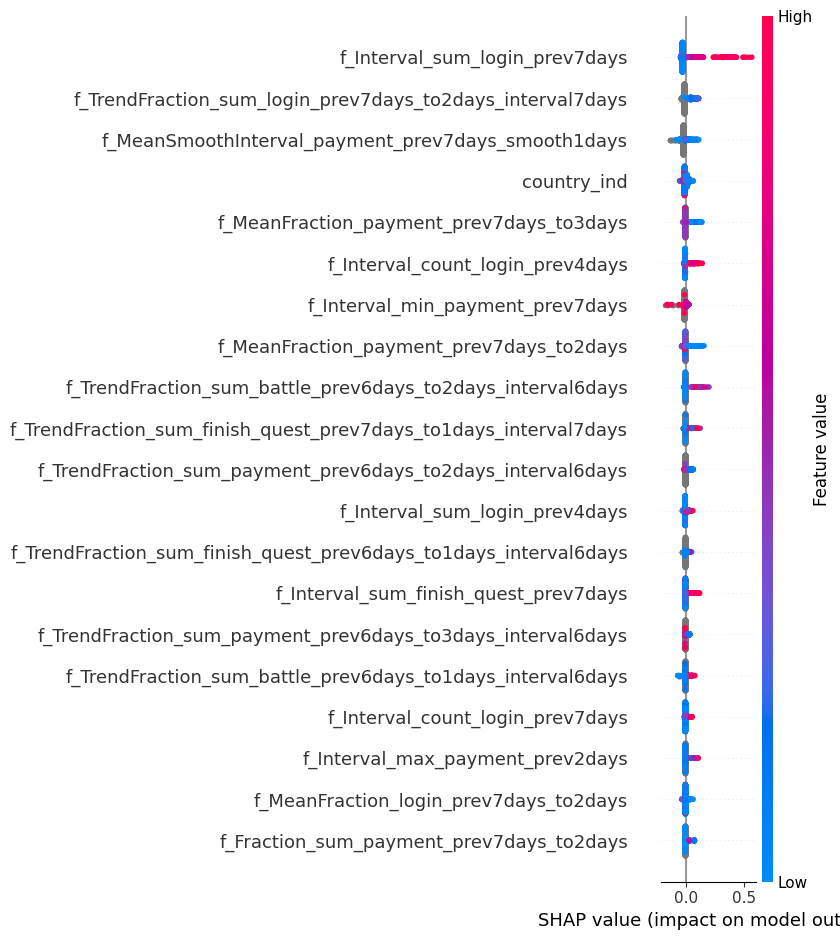

In [ ]:
top_features_df = get_shap_descr(trainer_actual_log_rate_full)

In [ ]:
top_n = 15
f_log_top_list = list(top_features_df.head(top_n)['feature'])
avg_rmse, std_rmse = trainer_actual_log_rate_full.train_folds(
    df=df_folds_5,
    folds=range(N_FOLDS),
    feature_space=f_log_top_list,
    target_name=TARGET_NAME,
    save_model=SAVE_MODEL,
    predict_model=True,
)

print(f"\nMean RMSE: {avg_rmse:.5f} ± {std_rmse:.5f}")


Mean RMSE: 0.40629 ± 0.03082


In [ ]:
trainer_actual_log_rate_full.df['cv_pred'] = ((np.exp(trainer_actual_log_rate_full.df['cv_pred'])-1)*(trainer_actual_log_rate_full.df['f_Interval_sum_payment_prev7days'])).fillna(0)

In [ ]:
pos_actual_target_seg = np.round(trainer_actual_log_rate_full.df['actual_target']>0, 9)
trainer_actual_log_rate_full.df.loc[pos_actual_target_seg, 'money_segment'] = True
trainer_actual_log_rate_full.df['money_segment'] = trainer_actual_log_rate_full.df['money_segment'].fillna(False)

In [ ]:
joblib.dump(trainer_actual_log_rate_full, f"{project_path}/artifacts/trainer_actual_log_rate_full.pickle")

['/content/drive/MyDrive/Colab Notebooks/scorewarrior/artifacts/trainer_actual_log_rate_full.pickle']

#### on LTV30-LTV7>0

/tmp/ipython-input-1177609859.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_regr['actual_log_rate_target'])


<Axes: xlabel='actual_log_rate_target', ylabel='Density'>

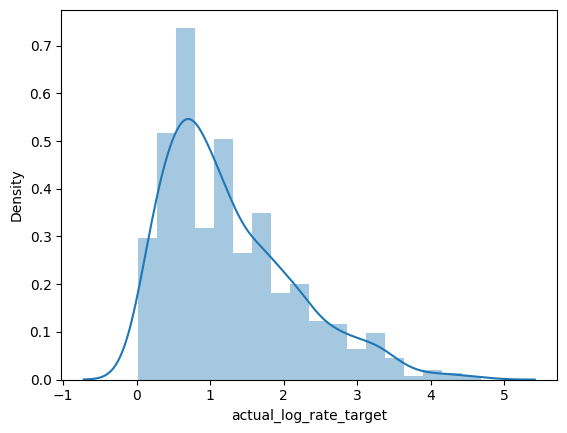

In [ ]:
sns.distplot(df_regr['actual_log_rate_target'])

In [ ]:
lgb_params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "reg_alpha":2.0,
    "reg_lambda":5.0,
    "min_child_samples":30,
    "max_depth": 3,
    "num_leaves":8,
    "verbosity": -1,
    "seed": 42,
    "num_boost_round": 1000,
    "early_stopping_rounds": 100,
    "n_jobs": 64,
}

TARGET_NAME = "actual_log_rate_target"
trainer_actual_log_rate = LGBMModel(params=lgb_params, model_name="lgbm", cat_features=CATEGORIES)

In [ ]:
avg_rmse, std_rmse = trainer_actual_log_rate.train_folds(
    df=df_regr,
    folds=range(10),
    feature_space=CATEGORIES+daily_features,
    target_name=TARGET_NAME,
    save_model=SAVE_MODEL,
    predict_model=True,
)

print(f"\nMean RMSE: {avg_rmse:.5f} ± {std_rmse:.5f}")


Mean RMSE: 0.79543 ± 0.12375


In [ ]:
trainer_actual_log_rate.df['cv_pred'] = ((np.exp(trainer_actual_log_rate.df['cv_pred'])-1)*(trainer_actual_log_rate.df['f_Interval_sum_payment_prev7days'])).fillna(0)

/tmp/ipython-input-1159779514.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X)


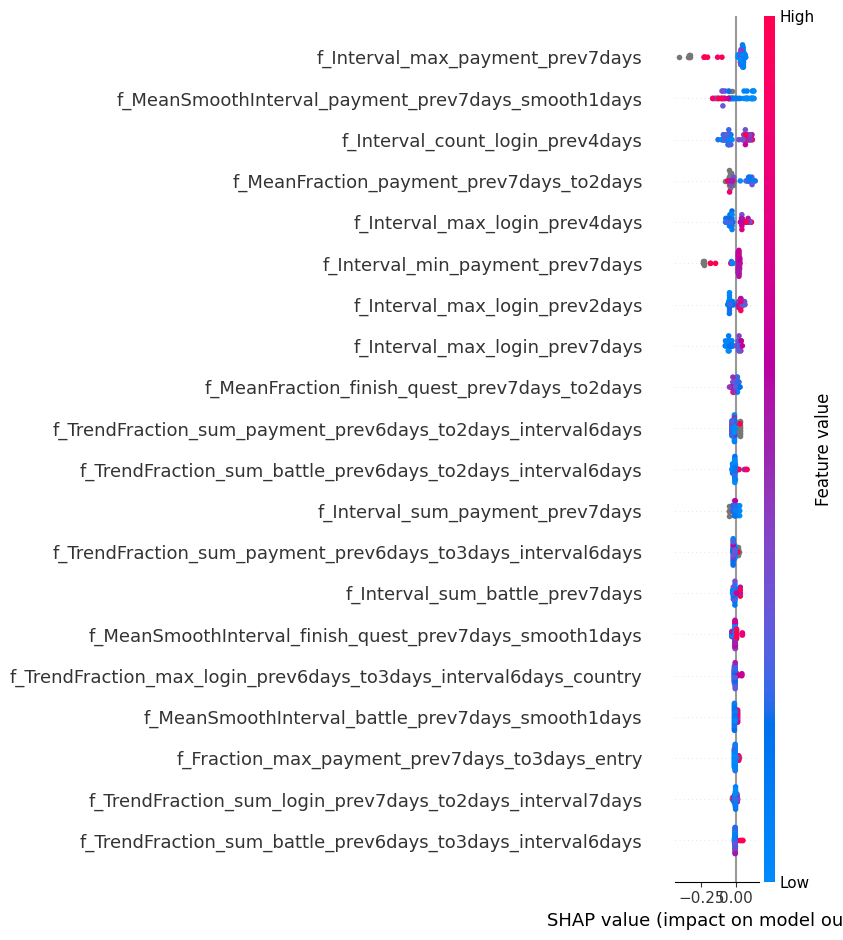

In [ ]:
top_features_df = get_shap_descr(trainer_actual_log_rate)

In [ ]:
top_n = 10
f_log_top_list = list(top_features_df.head(top_n)['feature'])
avg_rmse, std_rmse = trainer_actual_log_rate.train_folds(
    df=df_regr,
    folds=range(10),
    feature_space=f_log_top_list,
    target_name=TARGET_NAME,
    save_model=SAVE_MODEL,
    predict_model=True,
)

print(f"\nMean RMSE: {avg_rmse:.5f} ± {std_rmse:.5f}")


Mean RMSE: 0.77965 ± 0.11897


In [ ]:
trainer_actual_log_rate.df['cv_pred'] = ((np.exp(trainer_actual_log_rate.df['cv_pred'])-1)*(trainer_actual_log_rate.df['f_Interval_sum_payment_prev7days'])).fillna(0)

In [ ]:
joblib.dump(trainer_actual_log_rate, f"{project_path}/artifacts/trainer_actual_log_rate.pickle")

['/content/drive/MyDrive/Colab Notebooks/scorewarrior/artifacts/trainer_actual_log_rate.pickle']

#### VS

Нужно выбрать какой-то из двух регрессоров  
ну или никакой не выбирать, может LTV7 лучше будет)  
Ориентироваться буду только на сегмент LTV30-LTV7>0

In [ ]:
compare = pd.merge(
    (trainer_actual_log_rate_full
     .df[['cv_pred', 'user_id', 'f_Interval_sum_payment_prev7days']]
     .rename(columns={"cv_pred":"full_cv_pred"})),
    trainer_actual_log_rate.df[['cv_pred', 'user_id', 'actual_target', 'fold']],
    on=['user_id'],
    how='inner'
)

In [ ]:
compare['target_bin'] = pd.qcut(compare['actual_target'], 5)
compare['f_Interval_sum_payment_prev7days'] = compare['f_Interval_sum_payment_prev7days'].fillna(0)

In [ ]:
def get_bin_metrics_rep(x, pred_name, target_name):
  rmse = np.sqrt(mean_squared_error(y_true=x[target_name], y_pred=x[pred_name]))
  mae = mean_absolute_error(y_true=x[target_name], y_pred=x[pred_name])
  mape = mean_absolute_percentage_error(y_true=x[target_name], y_pred=x[pred_name])

  mean_pred = np.mean(x[pred_name])
  median_pred = np.median(x[pred_name])
  return pd.Series([rmse, mae, mape, mean_pred, median_pred],
                   ['rmse', 'mae', 'mape', 'mean_pred', 'median_pred'])

In [ ]:
compare.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="f_Interval_sum_payment_prev7days", target_name='actual_target'))

/tmp/ipython-input-1704611077.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compare.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="f_Interval_sum_payment_prev7days"))
/tmp/ipython-input-1704611077.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  compare.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="f_Interval_sum_payment_prev7days"))


,rmse,mae,mape,mean_pred,median_pred
target_bin,,,,,
"(11.032, 29.21]",122.479870,40.283736,1.655641,56.956864,24.451000
"(29.21, 81.782]",279.844993,92.295946,1.744939,115.081935,44.843661
"(81.782, 212.421]",179.150394,122.257993,0.911182,120.353373,57.610278
"(212.421, 736.847]",442.465827,320.615171,0.785031,193.235748,91.166716
"(736.847, 20376.846]",3998.068305,2484.922451,0.762420,692.690908,296.701278


In [ ]:
compare.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="full_cv_pred", target_name='actual_target'))

/tmp/ipython-input-2156911759.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compare.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="full_cv_pred"))
/tmp/ipython-input-2156911759.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  compare.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="full_cv_pred"))


,rmse,mae,mape,mean_pred,median_pred
target_bin,,,,,
"(11.032, 29.21]",217.584518,53.534174,2.219377,57.898868,13.365418
"(29.21, 81.782]",303.114325,93.835476,1.626087,106.702872,35.068470
"(81.782, 212.421]",228.553658,142.519105,1.074625,134.763805,46.680255
"(212.421, 736.847]",420.552669,327.558231,0.813435,227.069176,102.954821
"(736.847, 20376.846]",3561.326276,2106.040904,0.690313,1250.405734,522.912831


In [ ]:
compare.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="cv_pred", target_name='actual_target'))

/tmp/ipython-input-710932972.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compare.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="cv_pred"))
/tmp/ipython-input-710932972.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  compare.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="cv_pred"))


,rmse,mae,mape,mean_pred,median_pred
target_bin,,,,,
"(11.032, 29.21]",242.495710,103.406488,4.271830,120.155770,75.423090
"(29.21, 81.782]",566.787316,193.211200,3.452853,235.931616,113.295403
"(81.782, 212.421]",339.070423,182.540484,1.427494,256.893583,147.062915
"(212.421, 736.847]",432.235348,293.563775,0.729468,367.748319,198.902118
"(736.847, 20376.846]",3393.676045,1989.068698,0.611176,1515.600864,772.443458


In [ ]:
compare.groupby('fold').apply(partial(get_bin_metrics_rep, pred_name="f_Interval_sum_payment_prev7days", target_name='actual_target'))

/tmp/ipython-input-3447671769.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  compare.groupby('fold').apply(partial(get_bin_metrics_rep, pred_name="f_Interval_sum_payment_prev7days"))


,rmse,mae,mape,mean_pred,median_pred
fold,,,,,
0,2567.807891,690.748950,1.276947,207.540882,73.352999
1,1836.989718,592.270824,1.009475,206.619615,83.452105
2,2559.206145,839.668566,1.176663,202.185668,57.489107
3,728.381030,393.116164,0.920219,169.222429,73.352999
4,1751.247768,660.212701,0.753503,228.055657,47.800833
5,419.224299,213.532995,1.634597,276.078066,41.662356
6,2373.371867,936.936498,1.350301,273.134017,73.279499
7,1115.242679,428.963486,1.617023,334.240151,78.552817
8,1725.435160,721.892944,0.964932,319.864722,48.901999


In [ ]:
compare.groupby('fold').apply(partial(get_bin_metrics_rep, pred_name="full_cv_pred", target_name='actual_target'))

/tmp/ipython-input-1220254693.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  compare.groupby('fold').apply(partial(get_bin_metrics_rep, pred_name="full_cv_pred"))


,rmse,mae,mape,mean_pred,median_pred
fold,,,,,
0,2232.002814,650.684765,1.745312,323.586442,79.418763
1,1684.483541,475.490574,0.895294,317.788928,88.696151
2,2451.025232,756.883954,1.171390,308.035668,61.673125
3,611.996560,362.548102,1.023570,221.736347,71.211096
4,1327.282952,551.898005,0.810072,407.803201,44.699147
5,533.644150,266.462900,1.282310,319.136751,30.510826
6,2341.063066,860.716556,1.416497,342.981961,60.653042
7,947.121388,422.838229,2.653494,564.376725,62.627748
8,1137.958751,519.502162,0.882410,517.143295,39.345970


In [ ]:
compare.groupby('fold').apply(partial(get_bin_metrics_rep, pred_name="cv_pred", target_name='actual_target'))

/tmp/ipython-input-2681399204.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  compare.groupby('fold').apply(partial(get_bin_metrics_rep, pred_name="cv_pred"))


,rmse,mae,mape,mean_pred,median_pred
fold,,,,,
0,2000.427713,615.954759,2.256770,482.633967,187.803352
1,1689.730974,504.149784,1.846316,418.120242,200.504777
2,2125.523737,719.430874,1.866983,432.096960,132.217643
3,509.962463,316.350744,1.544190,406.712122,153.916930
4,1335.055746,525.187132,1.141510,466.367200,125.706164
5,457.350974,246.346999,2.342445,441.933799,112.578847
6,2366.227041,907.916234,2.516129,549.766707,191.552965
7,947.629272,460.652642,4.069695,727.058046,184.297510
8,1513.617899,636.264461,1.360763,700.410956,132.453361


в целом модель обученная на обрезанном трейне точнее  
точно кажется бесполезной модель обученная на всей выборке, тк средний и малый сегмент предсказывает хуже чем LTV7, а крупный сегмент хуже чем модель на урезанном трейне  
    
в частности она точнее скорее за счет того что лучше предсказывает хвост  
а LTV7 точнее на маленьком и среднем сегменте в частности  
  
кажется, что все-таки лучше взять эту модель чтобы хоть как-то предсказывать большие LTV  
(но разница не великая, данных для модели мало)  

### tweedie

#### on all train

In [ ]:
lgb_params = {
    "objective": "tweedie",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "tweedie_variance_power": 1.5,
    "num_leaves": 64,
    "max_depth": 7,

    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbosity": -1,
    "seed": 42,
    "num_boost_round": 100,

    "early_stopping_rounds": 100,
    "n_jobs": 64,
}

TARGET_NAME = "target"
trainer_tweedie = LGBMModel(params=lgb_params, model_name="lgbm", cat_features=CATEGORIES)

In [ ]:
avg_rmse, std_rmse = trainer_tweedie.train_folds(
    df=df_folds_5,
    folds=range(N_FOLDS),
    feature_space=CATEGORIES+daily_features,
    target_name=TARGET_NAME,
    save_model=SAVE_MODEL,
    predict_model=True,
)

print(f"\nMean RMSE: {avg_rmse:.5f} ± {std_rmse:.5f}")


Mean RMSE: 593.96746 ± 226.01480


/tmp/ipython-input-1159779514.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X)


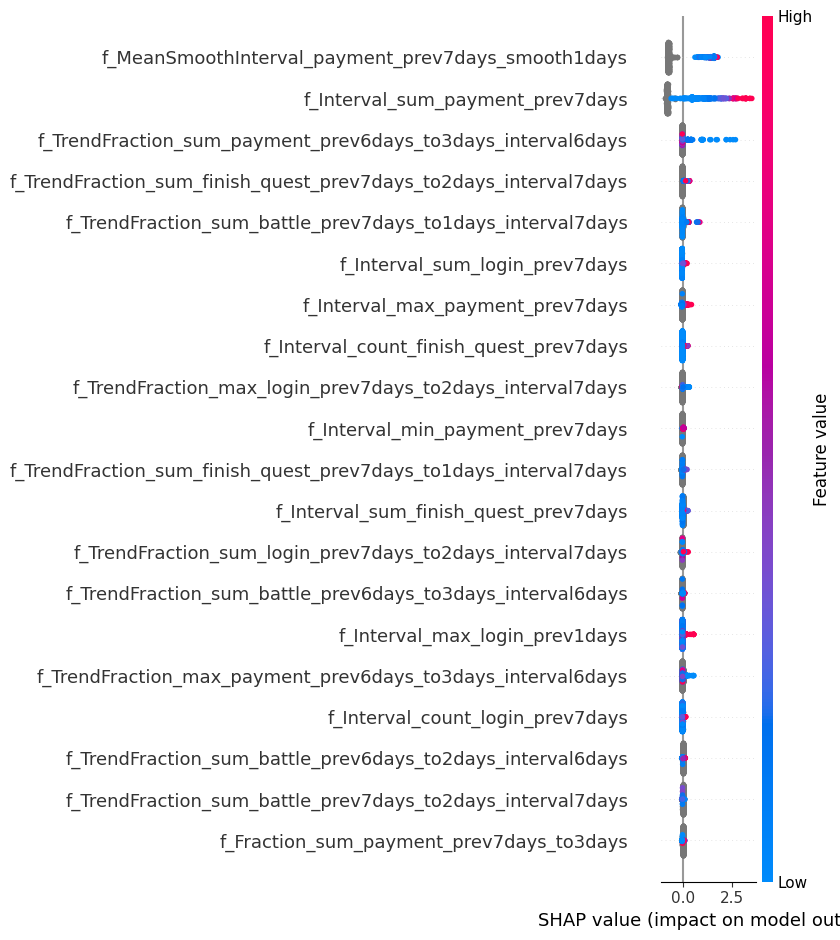

In [ ]:
top_features_df = get_shap_descr(trainer_tweedie)

In [ ]:
N_FOLDS = 5
top_n = 15
f_log_top_list = list(top_features_df.head(top_n)['feature'])
avg_rmse_top, std_rmse_top = trainer_tweedie.train_folds(
    df=df_folds_5,
    folds=range(N_FOLDS),
    feature_space=f_log_top_list,
    target_name=TARGET_NAME,
    save_model=SAVE_MODEL,
    predict_model=True,
)

print(f"\nMean RMSE: {avg_rmse:.5f} ± {std_rmse:.5f}")


Mean RMSE: 593.96746 ± 226.01480


In [ ]:
joblib.dump(trainer_tweedie, f"{project_path}/artifacts/trainer_tweedie.pickle")

['/content/drive/MyDrive/Colab Notebooks/scorewarrior/artifacts/trainer_tweedie.pickle']

# Metrics

In [ ]:
trainer_bin = joblib.load(f"{project_path}/artifacts/trainer_bin.pickle")
trainer_tweedie = joblib.load(f"{project_path}/artifacts/trainer_tweedie.pickle")
trainer_actual_log_rate = joblib.load(f"{project_path}/artifacts/trainer_actual_log_rate.pickle")

In [ ]:
train = pd.read_csv(f"{data_path}/train.csv")
train['f_Interval_sum_payment_prev7days_f'] = train['f_Interval_sum_payment_prev7days'].fillna(0)

## сбор скоров на train

In [ ]:
# так как выборка на регрессоре была урезана
# нужно собрать cv предсказания с урезанного трейна
# а все остальное скорить как тест
train['regr_pred'] = predict(trainer_actual_log_rate, train)
train['regr_pred'] = ((np.exp(train['regr_pred'])-1)*(train['f_Interval_sum_payment_prev7days'])).fillna(0)

train = pd.merge(train,
                trainer_actual_log_rate.df[['cv_pred', 'user_id']],
                on=['user_id'], how='left')
train['regr_pred'] = train['cv_pred'].combine_first(train['regr_pred'])

train = train.drop(columns=['cv_pred'])

In [ ]:
# по классификатору просто берем cv предсказания
train = pd.merge(train,
                  trainer_bin.df[['cv_pred', 'user_id']].rename(columns={"cv_pred":"bin_pred"}),
                  on=['user_id'], how='left')

In [ ]:
# по tweedie просто берем cv предсказания
train = pd.merge(train,
                  trainer_tweedie.df[['cv_pred', 'user_id']].rename(columns={"cv_pred":"tweedie_pred"}),
                  on=['user_id'], how='left')

In [ ]:
train['combine_pred'] = train['f_Interval_sum_payment_prev7days_f']+ train['bin_pred']*train['regr_pred']
train['base_pred'] = train['f_Interval_sum_payment_prev7days_f'] + train['bin_pred']*train['f_Interval_sum_payment_prev7days_f']
train['tweedie_pred_t'] = (train['bin_pred']*train['tweedie_pred'])
train['tweedie_pred_t'] = train[['tweedie_pred_t', 'f_Interval_sum_payment_prev7days_f']].max(1)

In [ ]:
train.loc[train['tweedie_pred_t'] <1, 'tweedie_pred_t'] = 0

In [ ]:
train.loc[train['combine_pred'] <1, 'combine_pred'] = 0

In [ ]:
train.to_csv(f"{data_path}/train.csv")

## расчет метрик и вывод

In [ ]:
get_metrics(train, 'target', 'f_Interval_sum_payment_prev7days_f')

{'rmse': np.float64(768.489513310602),
 'mae': 100.09849186211984,
 'mape': 0.08577505037173637}

In [ ]:
get_metrics(train, 'target', 'combine_pred')

{'rmse': np.float64(585.4152186228641),
 'mae': 87.86455881312729,
 'mape': 0.3049340928811171}

In [ ]:
get_metrics(train, 'target', 'base_pred')

{'rmse': np.float64(664.5163510158009),
 'mae': 89.90747988016727,
 'mape': 0.1695846423407771}

In [ ]:
get_metrics(train, 'target', 'tweedie_pred_t')

{'rmse': np.float64(626.0469599167733),
 'mae': 84.67441793114482,
 'mape': 0.14319517763565945}

In [ ]:
train['diff_combine'] = train['target'] - train['combine_pred']
train['diff_tweedie'] = train['target'] - train['tweedie_pred_t']
train['diff_base'] = train['target'] - train['base_pred']

In [ ]:
np.round(train[['diff_combine', 'diff_tweedie', 'diff_base']].describe(percentiles = [.25, .5, .75, .9, .95, .99]), 4)

,diff_combine,diff_tweedie,diff_base
count,4862.0000,4862.0000,4862.0000
mean,25.5094,48.7517,64.6381
std,585.1278,624.4054,661.4332
min,-7603.9832,-4294.9749,-2442.7345
25%,-8.9957,-0.0000,-2.0277
50%,0.0000,-0.0000,0.0000
75%,0.0000,-0.0000,0.0000
90%,0.0000,0.0000,8.9062
95%,65.6914,108.2716,156.6812
99%,1352.9705,1494.3160,1926.2207


In [ ]:
train['target_bin'] = pd.qcut(train['target'], 10, duplicates='drop')

In [ ]:
np.round(train.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="tweedie_pred_t", target_name='target')), 4)

/tmp/ipython-input-3737688562.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  np.round(train.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="tweedie_pred_t", target_name='target')), 4)
/tmp/ipython-input-3737688562.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  np.round(train.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="tweedie_pred_t", target_name='target')), 4)


,rmse,mae,mape,mean_pred,median_pred
target_bin,,,,,
"(-0.001, 24.451]",4.8798,0.4883,1.859292e+11,2.6413,0.0000
"(24.451, 48.804]",26.1824,10.4437,3.061000e-01,38.4565,30.6376
"(48.804, 137.612]",78.1430,36.7795,4.345000e-01,93.7716,73.3040
"(137.612, 22360.219]",1977.0387,806.0939,6.621000e-01,818.8302,301.5222


In [ ]:
np.round(train[train['target']<25][train['tweedie_pred_t']>0][['target', 'tweedie_pred_t', 'bin_pred']], 5).sort_values(by='tweedie_pred_t').tail(10)

/tmp/ipython-input-976830509.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  np.round(train[train['target']<25][train['tweedie_pred_t']>0][['target', 'tweedie_pred_t', 'bin_pred']], 5).sort_values(by='tweedie_pred_t').tail(10)


,target,tweedie_pred_t,bin_pred
1733,17.51635,70.52753,0.62548
3845,23.91149,70.77927,0.73254
4831,23.26750,73.86854,0.93935
3383,16.49993,80.08465,0.82691
87,22.25718,86.87589,0.78652
3576,23.78241,100.26848,0.80432
4224,24.45100,104.75076,0.75438
1111,22.24600,109.45284,0.45517
4288,24.45100,113.49879,0.57749
3015,24.02225,159.82334,0.71132


In [ ]:
np.round(train.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="base_pred", target_name='target')), 4)

/tmp/ipython-input-3856130529.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  np.round(train.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="base_pred", target_name='target')), 4)
/tmp/ipython-input-3856130529.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  np.round(train.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="base_pred", target_name='target')), 4)


,rmse,mae,mape,mean_pred,median_pred
target_bin,,,,,
"(-0.001, 24.451]",2.7164,0.7200,0.0332,2.8810,0.0000
"(24.451, 48.804]",16.8076,15.0793,0.4656,43.5959,41.6302
"(48.804, 137.612]",43.7381,36.2707,0.4458,94.6094,86.2289
"(137.612, 22360.219]",2099.1466,843.6824,0.5972,652.9430,275.3747


In [ ]:
np.round(train.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="combine_pred", target_name='target')), 4)

/tmp/ipython-input-2342502417.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  np.round(train.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="combine_pred", target_name='target')), 4)
/tmp/ipython-input-2342502417.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  np.round(train.groupby('target_bin').apply(partial(get_bin_metrics_rep, pred_name="combine_pred", target_name='target')), 4)


,rmse,mae,mape,mean_pred,median_pred
target_bin,,,,,
"(-0.001, 24.451]",7.1628,1.7017,0.0781,3.8799,0.0000
"(24.451, 48.804]",42.2645,35.3735,1.1293,65.1264,62.3610
"(48.804, 137.612]",94.9527,67.6480,0.8515,136.4894,117.0525
"(137.612, 22360.219]",1847.4966,776.5455,0.7179,976.3126,415.6221


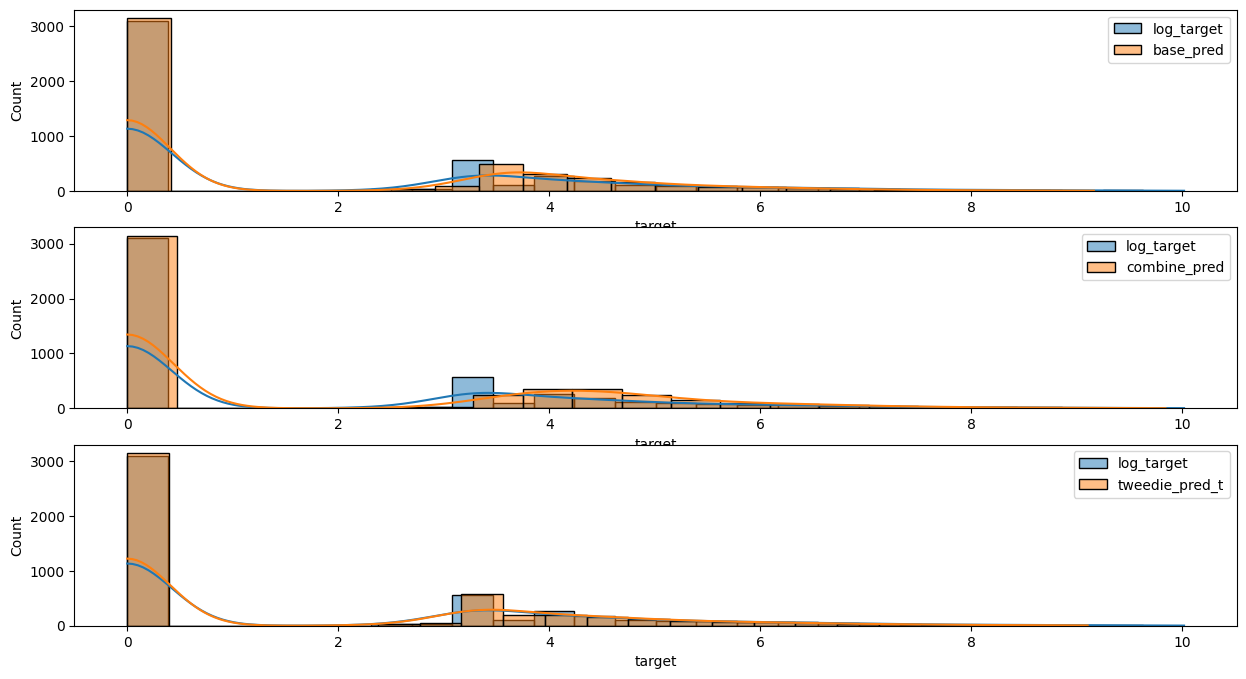

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 8))
sns.histplot(np.log(train["target"]+1), label="log_target", ax=ax1, kde=True)
sns.histplot(np.log(train["target"]+1), label="log_target", ax=ax2, kde=True)
sns.histplot(np.log(train["target"]+1), label="log_target", ax=ax3, kde=True)
sns.histplot(np.log(train['base_pred']+1), label="base_pred", ax=ax1, kde=True)
sns.histplot(np.log(train['combine_pred']+1), label="combine_pred", ax=ax2, kde=True)
sns.histplot(np.log(train['tweedie_pred_t']+1), label="tweedie_pred_t", ax=ax3, kde=True)
ax1.legend()
ax2.legend()
ax3.legend()
plt.show()

**Вывод**: если важнее угадывать большие LTV - лучше использовать combine_pred  
           если важнее угадывать большинство тех у кого LTV30>LTV7 - лучше брать tweedie

Мне кажется, что tweedie будет полезнее, так как хвост моделью combine_pred предсказывается несильно лучше и САМЫЕ большие LTV он все равно очень сильно занижает

Также tweedie кажется может стать немного лучше при переборе параметров и тщательной выборке фичей (через жадный отбор)


# Сохранение финальных артефактов

In [ ]:
trainer_bin = joblib.load(f"{project_path}/artifacts/trainer_bin.pickle")
trainer_tweedie = joblib.load(f"{project_path}/artifacts/trainer_tweedie.pickle")

In [ ]:
trainer_bin.custom_log[1]['num_boost_optimal']

131

In [ ]:
class_path = f"{project_path}/artifacts/final/classificator"
for fold, model in enumerate(trainer_bin.model_dict.values()):
  model.save_model(f"{class_path}/model_{fold}.txt")

In [ ]:
class_path = f"{project_path}/artifacts/final/regressor"
for fold, model in enumerate(trainer_tweedie.model_dict.values()):
  model.save_model(f"{class_path}/model_{fold}.txt")